### Ejercicio 6.1 (Agregar método ``min`` a un ABB)

El objetivo de este ejercicio es que usted agregue un método ``min`` a un árbol de búsqueda binaria. Este método debe entregar un puntero al nodo interno que contiene el elemento mínimo en un ABB. Para simplificar, usted puede suponer que el árbol siempre contiene al menos una llave.

In [26]:
import aed_utilities as aed

class Nodoi:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

class Nodoe:
    def __init__(self):
        pass

class Arbol:
    def __init__(self,raiz=Nodoe()):
        self.raiz=raiz

    def min(self):
        if isinstance(self.raiz, Nodoe):                                        #raiz no tiene hijo -> es min
            return self
        #si tiene hijo, hay que acceder a hijo:
        p = self.raiz

        while isinstance(p.izq.izq, Nodoi):                                             #si actual tiene hijo -> hijo es minimo
            p = p.izq                                                           #   aountar a hijo
                                                                                # se revisa de nuevo
        
        #salir de bucle: nodo actual es hoja -> es minimo
        return p.izq

    def insert(self,x):
        if isinstance(self.raiz, Nodoe):
            self.raiz=Nodoi(Nodoe(),x,Nodoe())
            return
        p=self.raiz
        while True:
            assert x!=p.info
            if x<p.info:
                if isinstance(p.izq, Nodoe):
                    p.izq=Nodoi(Nodoe(),x,Nodoe())
                    return
                p=p.izq
            else: # x>p.info
                if isinstance(p.der, Nodoe):
                    p.der=Nodoi(Nodoe(),x,Nodoe())
                    return
                p=p.der

    def search(self,x):
        p=self.raiz
        while not isinstance(p, Nodoe):
            if x==p.info:
                return p

                if x>p.info:
                    p = p.izq
                else:
                    p = p.der
        return None

    def dibujar(self):
      btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der", classNone=Nodoe, drawNull=True)
      btd.draw_tree(self, "raiz")

A continuación construimos un árbol para hacer pruebas y definimos una función para chequear que la respuesta esté correcta:

In [27]:
a=Arbol(
    Nodoi(
        Nodoi(
            Nodoi(Nodoe(),15,Nodoe()),
            20,
            Nodoi(
                Nodoi(Nodoe(),30,Nodoe()),
                35,
                Nodoe()
            )
        ),
        42,
        Nodoi(
            Nodoi(
                Nodoi(
                    Nodoi(Nodoe(),65,Nodoe()),
                    72,
                    Nodoi(Nodoe(),81,Nodoe())
                ),
                90,
                Nodoe()
            ),
            95,
            Nodoe()
        )
       )
)

def chequear(x,x_correcta):
  print("Respuesta:",x,"CORRECTA" if x==x_correcta else "ERROR")

A continuación ejecute las dos pruebas siguientes:

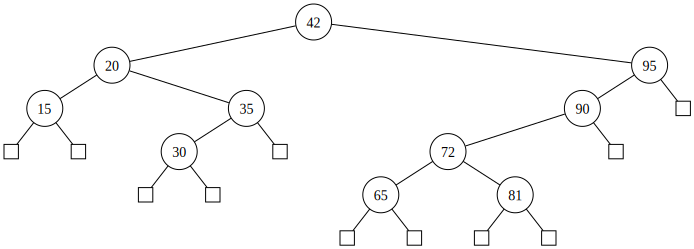

Respuesta: 15 CORRECTA


In [28]:
a.dibujar()
chequear(a.min().info,15)

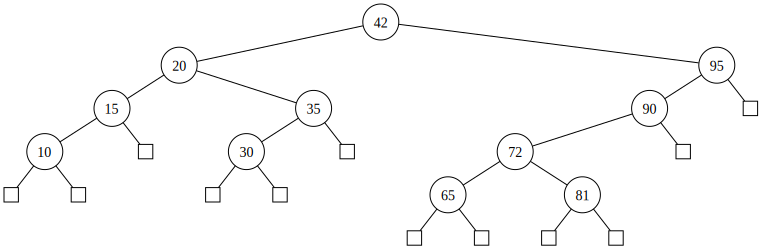

Respuesta: 10 CORRECTA


In [29]:
a.insert(10)
a.dibujar()
chequear(a.min().info,10)

### Ejercicio 6.2 (Ancestro común más bajo de dos nodos)

Dado un árbol de búsqueda binaria (ABB) y dos valores $p$ y $q$, encontrar el ancestro común más bajo (LCA, por sus siglas en inglés "Lowest Common Ancestor"). El LCA es el nodo más profundo del árbol que tiene a $p$ y a $q$ en su subárbol.

En la siguiente celda hay una implementación de un ABB. El ejercicio consiste en implementar la función LCA de la clase Arbol


In [ ]:
!pip install aed-utilities
import aed_utilities as aed

class Nodoi:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

    def search(self,x):
        if x==self.info:
            return self
        if x<self.info:
            return self.izq.search(x)
        else:
            return self.der.search(x)

    def insert(self,x):
        assert x!=self.info
        if x<self.info:
            return Nodoi(self.izq.insert(x),self.info,self.der)
        else:
            return Nodoi(self.izq,self.info,self.der.insert(x))

class Nodoe:
    def __init__(self):
        pass

    def search(self,x):
        return None

    def insert(self,x):
        return Nodoi(Nodoe(),x,Nodoe())


class Arbol:
    def __init__(self,raiz=Nodoe()):
        self.raiz=raiz

    def insert(self,x):
        self.raiz=self.raiz.insert(x)

    def search(self,x):
        return self.raiz.search(x)

    def LCA(self,x,y):
        pass

    def dibujar(self):
      btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der", classNone=Nodoe, drawNull=True)
      btd.draw_tree(self, "raiz")

Por ejemplo, en el ABB de abajo, el LCA entre 65 y 81 es 72, el LCA entre 30 y 65 es 42, y el LCA entre 95 y 105 es 95.

In [ ]:
a=Arbol(
    Nodoi(
        Nodoi(
            Nodoi(Nodoe(),15,Nodoe()),
            20,
            Nodoi(
                Nodoi(Nodoe(),30,Nodoe()),
                35,
                Nodoe()
            )
        ),
        42,
        Nodoi(
            Nodoi(
                Nodoi(
                    Nodoi(Nodoe(),65,Nodoe()),
                    72,
                    Nodoi(Nodoe(),81,Nodoe())
                ),
                90,
                Nodoe()
            ),
            95,
            Nodoi(Nodoe(), 100, Nodoi(Nodoe(), 105, Nodoe()))
        )
       )
)
a.dibujar()

Para testear tu función, realiza los siguientes tests:

In [ ]:
print("OK!" if a.LCA(65,81)==72 else "Error!")

In [ ]:
print("OK!" if a.LCA(30,65)==42 else "Error!")

In [ ]:
print("OK!" if a.LCA(95,105)==95 else "Error!")

### Ejercicio 6.3 (Chequear si un árbol es un ABB)

Dado un árbol binario, implementar una función que determine si el árbol es un árbol de búsqueda binaria válido. Esto significa comprobar que cada nodo cumple con las condiciones de un ABB.

In [ ]:
!pip install aed-utilities
import aed_utilities as aed

class Nodoi:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

    def search(self,x):
        if x==self.info:
            return self
        if x<self.info:
            return self.izq.search(x)
        else:
            return self.der.search(x)

    def insert(self,x):
        assert x!=self.info
        if x<self.info:
            return Nodoi(self.izq.insert(x),self.info,self.der)
        else:
            return Nodoi(self.izq,self.info,self.der.insert(x))


class Nodoe:
    def __init__(self):
        pass

    def search(self,x):
        return None

    def insert(self,x):
        return Nodoi(Nodoe(),x,Nodoe())


class Arbol:
    def __init__(self,raiz=Nodoe()):
        self.raiz=raiz

    def insert(self,x):
        self.raiz=self.raiz.insert(x)

    def search(self,x):
        return self.raiz.search(x)

    def esABB(arbol):
        pass

    def dibujar(self):
      btd = aed.BinaryTreeDrawer(fieldData="info", fieldLeft="izq", fieldRight="der", classNone=Nodoe, drawNull=True)
      btd.draw_tree(self, "raiz")

Para testear tu función, prueba los siguientes tests:

In [ ]:
a=Arbol(Nodoi(Nodoi(Nodoi(Nodoe(),10,Nodoe()),25,Nodoi(Nodoe(),40,Nodoe())),50,Nodoi(Nodoi(Nodoe(),12,Nodoe()),75,Nodoi(Nodoe(),90,Nodoe()))))
a.dibujar()

print("OK!" if a.esABB()==False else "Error!")


In [ ]:
b=Arbol(Nodoi(Nodoi(Nodoi(Nodoi(Nodoe(),8,Nodoe()),15,Nodoi(Nodoe(),22,Nodoe())),30,Nodoi(Nodoe(),45,Nodoe())),60,Nodoi(Nodoe(),80,Nodoi(Nodoe(),95,Nodoi(Nodoe(),110,Nodoe())))))
b.dibujar()

print("OK!" if b.esABB()==True else "Error!")

In [ ]:
c=Arbol(Nodoi(Nodoi(Nodoi(Nodoe(),18,Nodoi(Nodoe(),27,Nodoe())),33,Nodoi(Nodoe(),47,Nodoe())),55,Nodoi(Nodoi(Nodoe(),62,Nodoe()),70,Nodoi(Nodoi(Nodoi(Nodoe(),2,Nodoe()),80,Nodoe()),88,Nodoi(Nodoe(),99,Nodoe())))))
c.dibujar()

print("OK!" if c.esABB()==False else "Error!")

In [ ]:
d=Arbol(Nodoe())
d.dibujar()

print("OK!" if d.esABB()==True else "Error!")

### Ejercicio 6.4 (Chequear si un árbol es AVL en tiempo lineal)

En este ejercicio usted debe modificar la implementación dada para asegurar que cada nodo del árbol se visite solo una vez, asegurando de esta manera que el costo de determinar si un árbol es AVL sea $\Theta(n)$.

Para esto, usted debe fusionar las funciones ``altura`` y ``es_AVL``en una sola función ``altura_AVL``, que retorne una tupla $(h,a)$, donde $h$ es la altura y $a$ es un booleano que dice si el árbol es AVL. De esta manera, al invocar la función se tiene de una sola vez toda la información necesaria.

In [ ]:
class Nodoi:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

    def altura(self):
        return 1+max(self.izq.altura(),self.der.altura())

    def es_AVL(self):
        return abs(self.izq.altura()-self.der.altura())<=1 \
                and self.izq.es_AVL() and self.der.es_AVL()

class Nodoe:
    def __init__(self):
        pass

    def altura(self):
        return 0

    def es_AVL(self):
        return True


class Arbol:
    def __init__(self,raiz=Nodoe()):
        self.raiz=raiz

    def es_AVL(self):
        return self.raiz.es_AVL()


A continuación, pruébela con los dos árboles utilizados anteriormente:

In [ ]:
a1=Arbol(Nodoi(Nodoi(Nodoe(),1,Nodoe()),
            2,
            Nodoi(Nodoe(),3,Nodoi(Nodoe(),4,Nodoe()))))
print(a1)
print(a1.es_AVL())

In [ ]:
a2=Arbol(Nodoi(Nodoi(Nodoe(),1,Nodoe()),
            2,
            Nodoi(Nodoe(),3,Nodoi(Nodoe(),4,Nodoi(Nodoe(),5,Nodoe())))))
print(a2)
print(a2.es_AVL())

---

### Ejercicio 6.5 (Número de operaciones *split*)

Supongamos que comenzamos con un árbol 2-3 vacío y a continuación insertamos $n$ llaves. El objetivo de este ejercicio es calcular cuántas operaciones *split* se pueden llegar a ejecutar a lo largo de este proceso, en el peor caso.

Una manera de acotar este número de operaciones es ver que una inserción puede gatillar la ejecución de $O(\log{n})$ operaciones *split*, y como son $n$ inserciones, el número total de operaciones *split* es $O(n\log{n})$.

Lo anterior es una cota superior, pero en realidad está muy sobredimensionada.

Demuestre que el número total de operaciones *split* ejecutadas al insertar $n$ llaves comenzando con un árbol 2-3 vacío es $O(n)$ en el peor caso. Escriba su demostración en el siguiente recuadro.

*Indicación*: Considere el impacto de un *split* sobre el número de nodos del árbol.

#### Demostración:

---

### Ejercicio 6.6 : Búsqueda en árboles 2-3

El objetivo de esta tarea es que usted implemente la búsqueda ("search") en árboles 2-3 (sólo la búsqueda, no la inserción).
Para ello complete el código que implementa la función ``search`` en tres tipos de nodos:``Nodo2``, que almacena un nodo que tiene 2 hijos, ``Nodo3``, que tiene 3 y ``Nodoe`` que implementa un nodo externo. Además, la función ``search`` de la clase ``Arbol23`` está dada en el enunciado. En todos los casos, la función debe retornar un puntero al nodo que contiene la llave buscada en caso de ser exitosa, o ``None`` si es infructuosa. Usted puede decidir si usa un enfoque recursivo o no para implementarlo.

En varias partes se ha rellenado con código provisorio, para que compile. Usted debe reemplazar y completar todo lo que sea necesario para que todo funcione.

Para inspirarse puede ver operación de búsqueda ``search`` en un árbol binario en https://colab.research.google.com/github/ivansipiran/AED-Apuntes/blob/main/06_Diccionarios.ipynb#scrollTo=KTlzPSiLGRgy

In [ ]:
!pip install --upgrade aed-utilities

import aed_utilities as aed

class Nodo2:
    def __init__(self, izq, info, der):
        self.izq=izq
        self.info=info
        self.der=der

    def string(self):
      return "Nodo2("+str(self.info)+")"

    #Implementa esta función
    def search(self,x):
        pass

class Nodo3:
    def __init__(self, izq, info1, med, info2, der):
        self.izq=izq
        self.info1=info1
        self.med=med
        self.info2=info2
        self.der=der

    def string(self):
      return "Nodo3("+str(self.info1)+","+str(self.info2)+")"

    #Implementa esta función
    def search(self,x):
        pass

class Nodoe:
    def __init__(self):
        pass

    #Implementa esta función
    def search(self,x):
        pass

    def __str__(self):
      return "☐"

class Arbol23:
    def __init__(self,raiz=Nodoe()):
        self.raiz=raiz

    def search(self,x):
        return self.raiz.search(x)

    def dibujar(self):
        drawer = aed.Tree23Drawer(Nodo2, Nodo3, Nodoe)
        drawer.draw_tree(self)

Para probar este código, vamos a construir "a mano" el árbol 2-3 que aparece en el apunte, y luego hay que ejecutar las búsquedas que se indican, para probar que su solución esté correcta.

In [ ]:
a=Nodo3(Nodo2(Nodoe(),10,Nodoe()),25,Nodo3(Nodoe(),32,Nodoe(),48,Nodoe()),57,Nodo2(Nodoe(),74,Nodoe()))
arbol = Arbol23(a)
arbol.dibujar()

### Búsqueda de valores en un Árbol 2-3

In [ ]:
busqueda1=a.search(25)
assert busqueda1.string() == "Nodo3(25,57)"

busqueda2=a.search(74)
assert busqueda2.string() == "Nodo2(74)"


busqueda3=a.search(7)
assert busqueda3 == None

print("pasó los tests")

### Ejercicio 6.7 (Inserciones en una tabla de hashing con Linear Probing)

Suponga que se tiene una tabla de hashing con Linear Probing, de tamaño 10, inicialmente vacía, con la función de hashing $h(x) = x \bmod 10$ (por ejemplo, $h(64)=4$). Muestre en la siguiente tabla el resultado de insertar (a mano) la siguiente secuencia de llaves:

```
34, 59, 45, 27, 14, 22, 75, 25
```

![EjercicioLinearProbing](../recursos/EjercicioLinearProbing.png)

Utilizaremos la siguiente función para ver si su respuesta está correcta:

In [ ]:
def chequea_tabla(lista):
    h=0
    for x in lista:
        h = (h*100+x) % 100000007
    print("OK" if h==60375958 else "Error")

En el siguiente recuadro reemplace la lista de ceros por la lista de los elementos resultantes en la tabla. Si un casillero queda vacío, escriba un cero.

In [ ]:
chequea_tabla([0,0,0,0,0,0,0,0,0,0])

---

### Ejercicio 6.8 (Operaciones en un *trie*)

Consideremos el conjunto de llaves que aparece en el apunte

```
A = 00100
B = 01000
C = 01111
D = 11000
E = 11101
```

con las cuales se construye este *trie*:

![trie](https://github.com/ivansipiran/AED-Apuntes/blob/main/recursos/trie.png?raw=1)

A continuación ejecute (a mano) cada una de las operaciones que se indican, operando siempre sobre el árbol original, y dibuje en cada caso el árbol resultante:

1. Inserte ``F = 10110``

2. Inserte ``G = 00110``

3. Elimine ``E = 11101``